In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

import optuna 
import networkx as nx

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GCN, GAT

# GNN Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [3]:
DAT = DATA(load=True, model="GNN")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")     

Using device: cpu


In [4]:
DAT.train_in.shape, DAT.train_out.shape

((3588, 357, 2), (3588, 201))

In [5]:
perIN_ = DAT.perIN.reshape(int(len(DAT.perIN)/2), 2)
perIN_ = np.array([i for i in perIN_ if max(perIN_[:,0]) != i[0] and min(perIN_[:,0]) != i[0] and 
                                        max(perIN_[:,1]) != i[1] and min(perIN_[:,1]) != i[1]])
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [6]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [8, 32, 128]

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
n_epochs = 5000

In [7]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.train_in[:1000], DAT.train_outST[:1000])]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.val_in, DAT.val_outST)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(DAT.test_in, DAT.test_outST)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

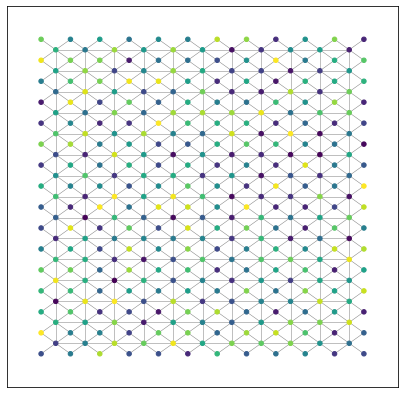

In [8]:
visualize_graphNetwork(train_dataloader, pos=perIN_, colors=None, layout="kk")

In [9]:
gcn1 = GCN(in_size, h_size, out_size, norm="batch", pool="mean").to(device)
gat1 = GAT(in_size, h_size, out_size, heads=1, norm="batch", pool="mean").to(device)
model = gat1

opt = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=25, min_delta=1e-8, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=8, threshold=1e-3, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [10]:
gat1, epoch, train_lossLog, val_lossLog = train_model('gnn', model, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, 
                                                      earlyStop=earlyStop, verbose=10)

Epoch: 1 - Loss: 0.33742237091064453
Epoch: 10 - Loss: 0.20713256299495697
Epoch: 20 - Loss: 0.11715535074472427
Epoch: 30 - Loss: 0.06620687991380692
Epoch: 40 - Loss: 0.03512436896562576
Epoch: 50 - Loss: 0.020730435848236084
Epoch: 60 - Loss: 0.013169219717383385
Epoch: 70 - Loss: 0.010147894732654095
Epoch: 80 - Loss: 0.007168450392782688
Epoch: 90 - Loss: 0.00734830554574728
Epoch: 100 - Loss: 0.006804396864026785
Epoch: 110 - Loss: 0.006273455452173948
Epoch: 120 - Loss: 0.005888274870812893
Epoch: 130 - Loss: 0.005486404988914728
Epoch: 140 - Loss: 0.005628575570881367
Epoch: 150 - Loss: 0.005117564462125301
Epoch: 160 - Loss: 0.005493536125868559
Epoch: 170 - Loss: 0.005129975266754627
Epoch: 180 - Loss: 0.005198740866035223
Epoch: 190 - Loss: 0.0050392453558743
Epoch: 200 - Loss: 0.005280160345137119
Epoch: 210 - Loss: 0.004822018090635538
Epoch: 220 - Loss: 0.005328990984708071
Epoch: 230 - Loss: 0.005226849112659693
Epoch: 240 - Loss: 0.005192504730075598
Epoch: 250 - Loss: 

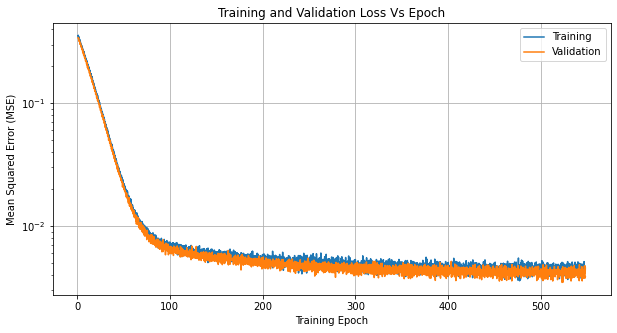

In [11]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [12]:
test_outputs = predict_model("gnn", model, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

In [13]:
err = list(sum(abs(DAT.test_out - test_outputs)))
err.index(min(err)), err.index(max(err))

(52, 91)

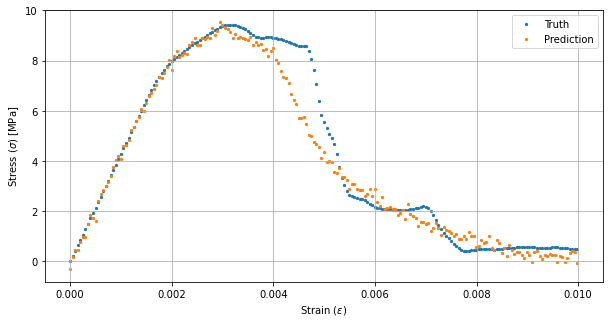

In [18]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs, indx=52)